# QUALITY MANAGEMENT
# Athens Metro Line 1 — Ridership & Capacity Simulation

## Overview

This notebook simulates and estimates passenger demand on [**Line 1 (Kifissia–Piraeus)**](https://en.wikipedia.org/wiki/Line_1_(Athens_Metro)) during weekday operations (Monday through Friday). Since there are limited open ridership data available for this line, our model is built on parameters derived from available literature, web sources, and observed patterns.

## Project Context

This notebook is part of a university project (Quality Management Course) aimed at identifying and analyzing a quality issue experienced by students in their daily life, and applying **Quality Management methodology** to propose solutions (e.g., Ishikawa diagrams).

## Scope

- **Period:** Spring semester, academic year 2025–2026  
- **Days covered:** Weekdays only (Monday–Friday)  
- **Exclusions:** Public holidays

## Imports
Following standard practice, and for the convenience of the reader, all imports will be placed at the beginning in the cell below.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import json

The data below originate from the analysis stored at `line1_data.ipynb`.

In [2]:
with open("sim_params.json") as f:
    sim_params = json.load(f)

day_multipliers = sim_params["day_multipliers"]
hourly_weights  = {int(k): v for k, v in sim_params["hourly_weights"].items()}
peak_hours      = set(sim_params["peak_hours"])
incident_prob   = sim_params["incident_prob"]

print("Day multipliers:", day_multipliers)
print("Incident prob:", incident_prob)
print("Peak hours:", sorted(peak_hours))
print("Hourly weights:", hourly_weights)

Day multipliers: [0.962, 0.979, 1.0, 1.085, 0.737]
Incident prob: 0.1053
Peak hours: [8, 9, 10, 15, 16, 17, 18, 19]
Hourly weights: {0: 0.0176, 1: 0.0068, 2: 0.0002, 3: 0.0, 4: 0.0, 5: 0.0007, 6: 0.0112, 7: 0.0355, 8: 0.0613, 9: 0.0717, 10: 0.0637, 11: 0.0527, 12: 0.0502, 13: 0.0507, 14: 0.055, 15: 0.0609, 16: 0.0686, 17: 0.0746, 18: 0.0758, 19: 0.0704, 20: 0.0577, 21: 0.0474, 22: 0.0403, 23: 0.0271}


## Schedule

Service patterns are modelled on the official [STASY Line 1 timetable](https://www.stasy.gr/%CE%B4%CF%81%CE%BF%CE%BC%CE%BF%CE%BB%CF%8C%CE%B3%CE%B9%CE%B1/%CE%B3%CF%81%CE%B1%CE%BC%CE%BC%CE%AE-1/),
with frequency and cancellation parameters calibrated against observed boarding patterns
recorded on the line during **February–May 2026**.

Hourly demand distribution is informed by open validation data published on
[data.gov.gr](https://www.data.gov.gr). The platform was discontinued in early May, 
however data until April 26 were extracted before the shutdown. The simulation is partially
based on them and they reveal two distinct demand peaks:

| Period | Hours | Type |
|---|---|---|
| Morning peak | 09:00 – 11:00 | Secondary peak |
| Evening peak | 16:00 – 19:30 | Dominant peak (busiest hour: ~18:00) |


The line operates daily from **05:30 to 00:30**,
covering 26 stations across approximately 25.6 km between Kifissia (north) and
Piraeus (south), passing through central Athens. The forementioned hourly demand distribution
is shown in the figure below:

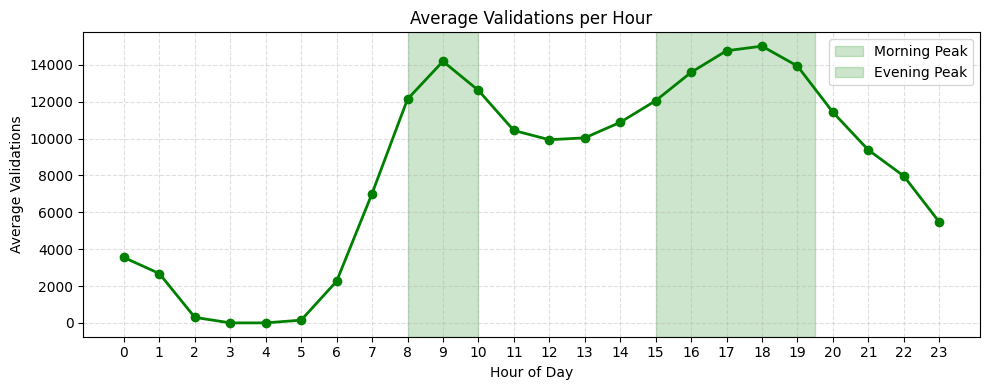

In [3]:
boarding_patterns = pd.read_excel("QFD_Hourly.xlsx")

avg_validations_by_hour = (
    boarding_patterns
    .groupby("trip_hour")["validations"]
    .mean()
    .round(2)
)

plt.figure(figsize=(10, 4))

plt.plot(
    avg_validations_by_hour.index,
    avg_validations_by_hour.values,
    marker="o",
    color= "green",
    linewidth=2
)

# Peak-hour shaded areas
plt.axvspan(8, 10, alpha=0.2, color="green", label="Morning Peak")
plt.axvspan(15, 19.5, alpha=0.2, color="green", label="Evening Peak")

plt.title("Average Validations per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Validations")

plt.xticks(range(24))
plt.grid(True, linestyle="--", alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()

In [4]:
schedule = [
    #start    end    sched_freq  actual_freq  loss_pct  is_peak
    #frequencies in minutes between trains
    #loss_pct = base cancellation rate before peak/day multipliers
    ["05:00", "05:30",   15,       15.5,        0.01,    False],
    ["05:30", "07:00",   7.5,       8,        0.01,    False],
    ["07:00", "08:00",    6,        6.5,         0.03,    False],
    ["08:00", "10:00",    6,        6.5,         0.05,    True], #morning peak (empirical: 09-10 highest AM hour)
    ["10:00", "15:00",    7.5,        8,         0.01,    False],
    ["15:00", "16:00",    6,        6.5,         0.02,    True],
    ["16:00", "18:00",    6,        6.5,         0.07,    True], #dominant evening peak (empirical: 17-19 busiest)
    ["18:00", "19:30",    7.5,        8,         0.07,    True], #dominant evening peak (empirical: 17-19 busiest)
    ["19:30", "22:30",    7.5,        8,         0.02,    False],
    ["22:30", "23:30",   12,       12.5,         0.01,    False],
    ["23:30", "01:30",   15,       15.5,         0.01,    False],
]

## Simulation Core — Day Model

Day-of-week multipliers are derived directly from real STASY validation data,
with **Wednesday as the baseline (1.0)**.

| Day | Mon | Tue | Wed | Thu | Fri |
|---|---|---|---|---|---|
| Multiplier | 0.962 | 0.979 | 1.000 | 1.085 | 0.737 |

Punctuality is defined as departure within **3 minutes** of schedule. A 3-minute threshold is appropriate for the Athens Metro because urban and commuter rail systems typically define punctuality within “3–5–6 min, depending on the country” [(Denti and Burroni, 2023)](https://www.mdpi.com/2276034) . Choosing the lower bound reflects that “passengers…are much less tolerant” and perceive even small delays negatively [(Denti and Burroni, 2023)](https://www.mdpi.com/2276034).

Delays follow a **log-normal distribution** (non-negative, heavy right tail) and
**cascade** between consecutive trips at a 40% bleed rate.

Cancellation rates are scaled by both peak status (1.6× peak / 0.8× off-peak)
and the day-of-week multiplier, so busier days carry proportionally higher disruption pressure.

In [5]:
#on-time threshold: 3 minutes
ON_TIME_THRESHOLD_MIN = 3.0

def time_to_minutes(t):
    h, m = map(int, t.split(":"))
    return h * 60 + m

def lognormal(mu, sigma):
    #a lot of small delays, few large delays 
    return random.lognormvariate(mu, sigma)

def simulate_day(day_index, incident_prob=0.02, weather_factor=1.0, cascade_bleed=0.4):
    #Simulate one operating day for Line 1.
    #Returns daily KPIs AND per-slot records (for consistent slot breakdown).
    day_mult = day_multipliers[day_index % 5]
    sched_total = 0
    actual_total = 0
    cancelled_total = 0
    frequency_gap_total = 0
    incidents = 0
    delays = []
    prev_delay = 0
    slot_records = []

    #sf -> scheduled frequency
    #af -> actual frequency
    for start, end, sf, af, loss_pct, is_peak in schedule:
        sm = time_to_minutes(start)
        em = time_to_minutes(end)
        if em < sm:
            em += 24 * 60
        duration = em - sm

        sched = int(duration / sf) #planned number of trains
        actual_raw = int(duration / af) #trains that could run given the spacing
        peak_mult = 1.6 * day_mult if is_peak else 0.8 * day_mult

        #simulate cancelation rate based on weekday performance, weather, hour of day and randomness
        loss_pct_actual = max(0, random.gauss(loss_pct * (1 + 0.5*(weather_factor - 1)) *
                                                  (1.6 if is_peak else 0.8), 0.02))
        
        frequency_gap = sched - actual_raw # trains lost to wider headway
        cancelled = int(sched * loss_pct_actual) # trains cancelled on top of gap
        actual = max(0, sched - frequency_gap - cancelled) # trains that actually run

        sched_total += sched
        actual_total += actual
        cancelled_total += cancelled
        frequency_gap_total += frequency_gap

        slot_records.append({
            "slot": f"{start}\u2013{end}",
            "scheduled": sched,
            "actual": actual,
            "cancelled": cancelled,
            "is_peak": is_peak
        })

        for _ in range(actual):
            #delay per train based on day, weather and randomness
            delay = lognormal(0.3, 0.7) * peak_mult * weather_factor
            delay += prev_delay * cascade_bleed
            if random.random() < incident_prob:
                delay += random.uniform(5, 25)
                incidents += 1
            delay = max(0, delay)
            prev_delay = delay
            delays.append(delay)
        prev_delay *= 0.3 #partial impact of delay between time-slots

    avg_delay = sum(delays) / len(delays)
    on_time_pct = sum(1 for d in delays if d < ON_TIME_THRESHOLD_MIN) / len(delays) * 100

    return {
        "scheduled": sched_total,
        "actual": actual_total,
        "cancelled": cancelled_total,
        "avg_delay_min": round(avg_delay, 2),
        "on_time_pct": round(on_time_pct, 1),
        "incidents": incidents,
        "slot_records": slot_records
    }

## Simulation Run — 63 Workdays (Feb–May 2026)

The simulation covers **63 workdays** from 16 February to 15 May 2026.
It should be acknowledged that `the simulation is direction-agnostic` and therefore
supposes that there is no difference between the Kiffisia-Piraeus and 
Piraeus-Kiffisia direction in terms of rideship, incidents..etc

Weather conditions are sampled probabilistically per month, reflecting Athens'
typical late-winter/early-spring climate:

| Month | Rain probability | Storm probability |
|---|---|---|
| February | 25% | 5% |
| March | 20% | 3% |
| April | 12% | 1% |
| May | 5% | 1% |

A storm applies a **1.5× delay multiplier**; rain applies **1.1×**; clear weather has no effect.
Each day is simulated independently with `incident_prob = 0.02` (2% chance per trip).

In [16]:
greek_holidays = ["2026-02-23", "2026-03-25", "2026-04-10", "2026-04-13", "2026-01-5"]
all_bdays = pd.bdate_range("2026-02-16", "2026-05-15")
workdays = [d for d in all_bdays if str(d.date()) not in greek_holidays][:63]

print(f"Simulation window: {workdays[0].date()} → {workdays[-1].date()}")
print(f"Total workdays: {len(workdays)}\n")

def get_weather(month):
    probs = {2: (0.25, 0.05), 
             3: (0.20, 0.03), 
             4: (0.12, 0.01), 
             5: (0.05, 0.01)}
    
    rain_p, storm_p = probs.get(month, (0.20, 0.02))
    r = random.random()
    if r < storm_p:            return ("storm", 1.5)
    elif r < storm_p + rain_p: return ("rain",  1.1)
    else:                      return ("clear", 1.0)

cascade_bleed  = 0.4
random.seed(42)
results = []
for date in workdays:
    weather_condition, weather_factor = get_weather(date.month)
    r = simulate_day(date.weekday(), incident_prob, weather_factor, cascade_bleed)
    r["date"]    = date
    r["weekday"] = date.day_name()
    r["month"]   = date.strftime("%B")
    r["weather"] = weather_condition
    results.append(r)

for i, r in enumerate(results, 1):
    # is calculated per direction and columns ran, schedules and incidentsis multiplied
    # by two to show the whole line
    print(f"Day {i:>2} ({r['weekday'][:3]} {r['date'].strftime('%d %b')}) [{r['weather']:<5}]: "
          f"ran {2 * r['actual']}/{2 * r['scheduled']} | "
          f"cancelled {2 * r['cancelled']} | "
          f"avg delay {r['avg_delay_min']} min | "
          f"on-time {r['on_time_pct']}% | "
          f"incidents {2 * r['incidents']}")

print("\n--- 63-Day Averages ---")
n = len(results)

for key in ["scheduled", "actual", "cancelled", "avg_delay_min", "on_time_pct", "incidents"]:
    avg = sum(
        2 * r[key] if key in ["scheduled", "actual", "cancelled", "incidents"]
        else r[key]
        for r in results
    ) / n

    print(f"  {key}: {avg:.2f}")

Simulation window: 2026-02-16 → 2026-05-15
Total workdays: 61

Day  1 (Mon 16 Feb) [clear]: ran 288/326 | cancelled 6 | avg delay 5.04 min | on-time 51.4% | incidents 30
Day  2 (Tue 17 Feb) [clear]: ran 286/326 | cancelled 8 | avg delay 6.4 min | on-time 41.3% | incidents 34
Day  3 (Wed 18 Feb) [clear]: ran 286/326 | cancelled 8 | avg delay 5.16 min | on-time 46.9% | incidents 26
Day  4 (Thu 19 Feb) [rain ]: ran 284/326 | cancelled 10 | avg delay 5.75 min | on-time 35.2% | incidents 22
Day  5 (Fri 20 Feb) [rain ]: ran 284/326 | cancelled 10 | avg delay 4.8 min | on-time 52.8% | incidents 32
Day  6 (Tue 24 Feb) [clear]: ran 286/326 | cancelled 8 | avg delay 6.43 min | on-time 32.9% | incidents 34
Day  7 (Wed 25 Feb) [clear]: ran 286/326 | cancelled 8 | avg delay 5.48 min | on-time 51.0% | incidents 26
Day  8 (Thu 26 Feb) [clear]: ran 284/326 | cancelled 10 | avg delay 5.44 min | on-time 39.4% | incidents 30
Day  9 (Fri 27 Feb) [storm]: ran 282/326 | cancelled 12 | avg delay 5.49 min | o

The simulation results suggest that, across the 63 examined workdays, only about 285 of the 326 
daily scheduled train services were ultimately executed, with an average delay of approximately
5.7 minutes per service and an on-time performance rate of 44.88%. Approximately 8.6 of the 
missing services can be directly attributed to cancellations, while the remainder stem from
operational inefficiencies caused by widened headways and accumulated delays. According to the
simulation, these disruptions are particularly pronounced during peak periods, where cascading
delays reduce the system’s ability to recover timetable regularity.

These findings appear consistent with reported operational issues on Line 1. Senior STASY managers
have stated that “there are 3–4 train malfunctions happening daily”, while Stamatis Giannopoulos,
president of the STASY workers’ union, noted that “when a train malfunctions it is withdrawn and if
there is none to replace it, the train’s itinerary is cancelled” 
([Kathimerini, 2024](https://www.kathimerini.gr/society/reportaz/563749864/isap-i-istoriki-alla-provlimatiki-grammi-1/)).
Such statements support the assumption that part of the observed service suppression may be linked to rolling stock availability and maintenance limitations.

However, the simulation also indicates that not all lost service is caused by outright technical failures.
Smaller operational disturbances — such as minor driver delays, increased dwell times, or timetable
deviations — can accumulate throughout the day due to cascading effects, ultimately leading to missed 
or effectively suppressed train services even without formal cancellations.

A further indication of the simulation’s credibility is its consistency with reported yearly operational
figures. According to the same article, the total number of executed train services on Line 1 was 102,442
in 2023 and 96,455 in 2024. Aggregating the simulation’s results to a yearly estimate yields:

\
\begin{aligned}
\text{Estimated yearly executed services} \; &= \;
\underbrace{285,42 \times 365 \times \frac{5}{7}}_{\text{Weekday operations}}
\\[6pt]
&\quad + \;
\underbrace{(285.42 \times 0.8) \times 365 \times \frac{2}{7}}_{\text{Weekend operations (assumed 20\% lower)}}
\\[10pt]
&\approx 98{,}225
\end{aligned}


This estimated yearly total differs from the reported 2024 value by only about 2%, suggesting that the
simulation produces results that are reasonably aligned with observed operational performance.

## Per-Slot Breakdown

Trip counts were aggregated by time slot across all 63 simulated workdays. The *suppressed* column 
captures all services that were not ultimately executed, including both explicitly cancelled trips
and those effectively lost due to widened headways between scheduled and actual train frequencies.

The results indicate that the evening peak period (16:00–20:00) experiences the highest operational 
pressure and the greatest concentration of service loss. In particular, the 16:00–18:00 slot exhibits
the highest cancellation rate at 8.4%, while the broader 16:00–20:00 evening peak consistently records
the largest number of suppressed services overall. This reflects both the elevated cancellation 
multipliers applied during peak periods and the increased vulnerability of the system to cascading delays
under high passenger demand.

Similarly, the morning peak period (08:00–10:00) also demonstrates significant operational strain, with
an average cancellation rate of 5.8% and more than three suppressed services per simulated day. In contrast,
off-peak and late-night periods maintain near-perfect operational stability, exhibiting minimal cancellations
and consistently low suppression levels.

Overall, the slot-level analysis suggests that Line 1’s reliability issues are concentrated primarily during
periods of maximum passenger demand rather than being evenly distributed throughout the day. This supports the
interpretation that the system operates close to its operational limits during peak hours, where even
relatively minor disruptions can propagate and significantly reduce timetable adherence.

In [7]:
all_slot_records = []
for r in results:
    all_slot_records.extend(r["slot_records"])

slot_order = [f"{s}\u2013{e}" for s, e, *_ in schedule]

slot_df = pd.DataFrame(all_slot_records)
avg_by_slot = (
    slot_df.groupby("slot")[["scheduled", "actual", "cancelled"]]
    .mean()
    .round(2)
    .reindex(slot_order)
)
avg_by_slot["cancellation_rate"] = (
    slot_df.groupby("slot")["cancelled"].sum() /
    slot_df.groupby("slot")["scheduled"].sum()
    * 100
).round(1)
avg_by_slot["suppressed"] = (
    avg_by_slot["scheduled"] - avg_by_slot["actual"]
).round(2)

avg_by_slot

,scheduled,actual,cancelled,cancellation_rate,suppressed
slot,,,,,
05:00–05:30,2.0,1.00,0.00,0.0,1.00
05:30–07:00,12.0,11.00,0.00,0.0,1.00
07:00–08:00,10.0,9.00,0.00,0.0,1.00
08:00–10:00,20.0,16.92,1.08,5.4,3.08
10:00–15:00,40.0,36.85,0.15,0.4,3.15
15:00–16:00,10.0,9.00,0.00,0.0,1.00
16:00–18:00,20.0,16.21,1.79,9.0,3.79
18:00–19:30,12.0,10.03,0.97,8.1,1.97
19:30–22:30,24.0,21.89,0.11,0.5,2.11


## Capacity Estimation

Line 1 operates three rolling [stock variants](https://el.wikipedia.org/wiki/%CE%A4%CF%81%CE%BF%CF%87%CE%B1%CE%AF%CE%BF_%CF%85%CE%BB%CE%B9%CE%BA%CF%8C_%CE%BC%CE%B5%CF%84%CF%81%CF%8C_%CE%91%CE%B8%CE%AE%CE%BD%CE%B1%CF%82#%CE%93%CF%81%CE%B1%CE%BC%CE%BC%CE%AE_1) with different passenger capacities.
Each branch contributes to a fleet-weighted average capacity per train:

| Branch | Capacity (pax) | Fleet share |
|---|---:|---:|
| Branch 8 | 830 | 25% |
| Branch 11 | 1,002 | 60% |
| Branch 1 | 1,030 | 15% |

The train manufacturers calculate maximum passenger capacity as the sum of seated passengers 
and standing passengers, assuming a maximum density of approximately five standing passengers
per square meter.

**Weighted average intended capacity: ~963 passengers per train.**

This represents the train’s maximum passenger occupancy at a specific moment in time. However,
the objective of the simulation is to approximate the total passenger carrying capability of a
train throughout its full journey on Line 1. In practice, passengers continuously board and 
disembark at intermediate stations, allowing available passenger space to be reused multiple
times during a route. Consequently, the cumulative number of passengers transported by a train
can substantially exceed its instantaneous onboard occupancy.

To account for this effect, a turnover multiplier is introduced to represent the average reuse
of available passenger space throughout a train journey. Based on on-site observations and personal
experience using the line, it is conservatively approximated that  about 5% of onboard passengers 
disembark and are replaced at each station on average. While this assumption does not account for 
differences in passenger turnover between stations, it provides  a simplified approximation of
cumulative passenger circulation along the line.

Assuming approximately 23 inter-station segments across the full route, the turnover multiplier is estimated as:

\
\begin{aligned}
\text{Turnover Multiplier}
&=
1 + \left(0.05 \times 23\right)
\\[6pt]
&=
1 + 1.15
\\[6pt]
&= 2.15
\end{aligned}


This suggests that the effective passenger carrying capability of a train over the course of a full journey
is approximately double its instantaneous occupancy capacity.

The resulting effective carrying capacity figures are subsequently multiplied by the average scheduled and 
actual train counts per time slot in order to estimate:
- the theoretical passenger capacity planned by the timetable,
- and the passenger capacity effectively delivered under simulated operating conditions.

These estimates are then compared against approximated passenger demand in order to evaluate load factors 
and identify periods where Line 1 operates under the greatest operational pressure.

It should be noted that the fleet share percentages are not based on official published statistics, but rather
on repeated observation of rolling stock circulation patterns throughout the simulation period. Furthermore, the 
turnover approximation constitutes a simplified modeling assumption intended to approximate cumulative carrying 
capability rather than exact passenger movement dynamics.

In [8]:
branches = {
    'branch_8':  (830, 0.25),
    'branch_11': (1002, 0.60),
    'branch_1':  (1030, 0.15),
}

TURNOVER = 2.15

total_weight = sum(w for p, w in branches.values())
assert abs(total_weight - 1.0) < 1e-9, f"Branch weights must sum to 1.0, got {total_weight}"

avg_capacity_limited = sum(p * w for p, w in branches.values()) * TURNOVER

slot_durations = {
    '05:00–05:30': 0.5, '05:30–07:00': 1.5, '07:00–08:00': 1, '08:00–10:00': 2,
    '10:00–15:00': 5, '15:00–16:00': 1, '16:00–18:00': 2, '18:00–19:30': 1.5,
    '19:30–22:30': 3, '22:30–23:30': 1, '23:30–01:30': 2,
}

avg_by_slot['capacity_actual']    = (avg_by_slot['actual']    * avg_capacity_limited).round(0)
avg_by_slot['capacity_scheduled'] = (avg_by_slot['scheduled'] * avg_capacity_limited).round(0)

In [9]:
def slot_demand_weight(start, end):
    sm_min = time_to_minutes(start)
    em_min = time_to_minutes(end)
    if em_min < sm_min:  #genuine overnight (e.g. 23:30–01:30)
        em_min += 24 * 60

    sm = sm_min // 60
    em = em_min // 60  #exclusive upper bound

    return sum(hourly_weights.get(h % 24, 0) for h in range(sm, em))

In [10]:
REAL_DAILY_BOARDINGS = 213_660 #from data extracted by gov
ONE_DIR_BOARDINGS = REAL_DAILY_BOARDINGS / 2

avg_by_slot["demand_weight"] = [
    slot_demand_weight(s, e) for s, e, *_ in schedule
]
avg_by_slot["estimated_demand"] = (
    avg_by_slot["demand_weight"] * ONE_DIR_BOARDINGS
).round(0)

avg_by_slot["load_factor"] = (
    avg_by_slot["estimated_demand"] / avg_by_slot["capacity_actual"]
).round(3)

In [11]:
avg_by_slot

,scheduled,actual,cancelled,cancellation_rate,suppressed,capacity_actual,capacity_scheduled,demand_weight,estimated_demand,load_factor
slot,,,,,,,,,,
05:00–05:30,2.0,1.00,0.00,0.0,1.00,2071.0,4142.0,0.0000,0.0,0.000
05:30–07:00,12.0,11.00,0.00,0.0,1.00,22780.0,24851.0,0.0119,1271.0,0.056
07:00–08:00,10.0,9.00,0.00,0.0,1.00,18638.0,20709.0,0.0355,3792.0,0.203
08:00–10:00,20.0,16.92,1.08,5.4,3.08,35039.0,41418.0,0.1330,14208.0,0.405
10:00–15:00,40.0,36.85,0.15,0.4,3.15,76312.0,82835.0,0.2723,29090.0,0.381
15:00–16:00,10.0,9.00,0.00,0.0,1.00,18638.0,20709.0,0.0609,6506.0,0.349
16:00–18:00,20.0,16.21,1.79,9.0,3.79,33569.0,41418.0,0.1432,15298.0,0.456
18:00–19:30,12.0,10.03,0.97,8.1,1.97,20771.0,24851.0,0.0758,8098.0,0.390
19:30–22:30,24.0,21.89,0.11,0.5,2.11,45332.0,49701.0,0.1755,18749.0,0.414


In [12]:
print(f"Avg daily capacity (actual):    {avg_by_slot['capacity_actual'].sum():,.0f}")
print(f"Avg daily capacity (scheduled): {avg_by_slot['capacity_scheduled'].sum():,.0f}")
print(f"Avg daily demand (real data, total): {REAL_DAILY_BOARDINGS:,.0f}")
print(f"Overall load factor: {ONE_DIR_BOARDINGS / avg_by_slot['capacity_actual'].sum():.3f}")

peak_slots = [
    "08:00–10:00",
    "16:00–18:00",
    "18:00–19:30"
]

peak_demand = avg_by_slot[
    avg_by_slot.index.isin(peak_slots)
]["estimated_demand"].sum()

peak_capacity = avg_by_slot[
    avg_by_slot.index.isin(peak_slots)
]["capacity_actual"].sum()

print(f"Peak-hour load factor: {peak_demand / peak_capacity:.3f}")

Avg daily capacity (actual):    295,930
Avg daily capacity (scheduled): 337,555
Avg daily demand (real data, total): 213,660
Overall load factor: 0.361
Peak-hour load factor: 0.421


The simulation estimates an average effective daily carrying capacity of approximately 295,930 passengers
under actual operating conditions, compared to a theoretical scheduled capacity of approximately 337,555
passengers. When compared against the estimated real-world daily ridership of 213,660 passenger boardings,
the resulting overall load factor is approximately 0.361. This suggests that, in aggregate terms, Line 1 
operates at roughly 36% of its estimated effective cumulative carrying capacity.

During peak periods, however, the load factor rises to approximately 0.421, indicating substantially higher
operational pressure during high-demand intervals. Although the system still appears to retain theoretical
spare carrying capacity overall, the concentration of passenger demand within relatively narrow time windows 
increases the likelihood of localized overcrowding, platform congestion, and cascading operational delays.

These findings support the interpretation that the principal challenge faced by Line 1 is not necessarily 
insufficient total daily capacity, but rather the uneven temporal distribution of passenger demand and the 
reduced operational resilience of the system during peak-hour conditions.

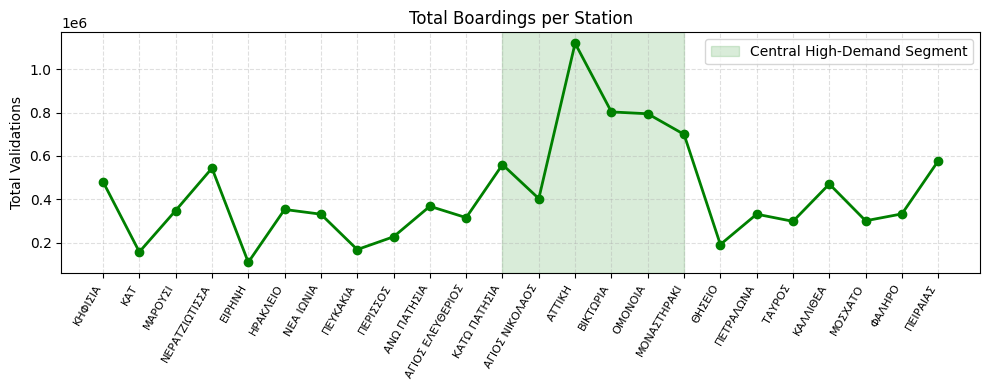

In [13]:
boardings = pd.read_excel("QFD.xlsx")

station_totals = (
    boardings
    .groupby(["station_order", "station"])["validations"]
    .sum()
    .reset_index()
    .sort_values("station_order")
)

plt.figure(figsize=(10, 4))

plt.plot(
    station_totals["station"],
    station_totals["validations"],
    marker="o",
    linewidth=2,
    color="green"
)

start_idx = station_totals.index[
    station_totals["station"] == "ΚΑΤΩ ΠΑΤΗΣΙΑ"
][0]

end_idx = station_totals.index[
    station_totals["station"] == "ΜΟΝΑΣΤΗΡΑΚΙ"
][0]

plt.axvspan(
    start_idx,
    end_idx,
    color="green",
    alpha=0.15,
    label="Central High-Demand Segment"
)

plt.title("Total Boardings per Station")
plt.ylabel("Total Validations")

plt.xticks(
    range(len(station_totals)),
    station_totals["station"],
    size=8,
    rotation=60,
    ha="right"
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

It is evident from the graph above that the stations serving the central areas of Athens exhibit 
substantially higher boarding volumes compared to those located in the suburban sections of the line.
This pattern becomes particularly pronounced from ΚΑΤΩ ΠΑΤΗΣΙΑ to ΜΟΝΑΣΤΗΡΑΚΙ, where passenger demand 
intensifies significantly as the line approaches the city center. A plausible explanation is that 
central Athens functions as the city’s primary economic, commercial, and educational hub, concentrating
a large share of workplaces, services, and universities. Consequently, a substantial number of passengers 
travel toward the center for work, study, and commercial activities.

This interpretation is further supported by the fact that stations such as ΝΕΡΑΤΖΙΩΤΙΣΣΑ and ΠΕΙΡΑΙΑΣ — both
associated with significant commercial and transportation activity — also exhibit noticeably higher boarding
volumes than most suburban stations. In the case of ΝΕΡΑΤΖΙΩΤΙΣΣΑ, this is likely reinforced by the presence 
of major commercial centers and its connection with the suburban railway network, while ΠΕΙΡΑΙΑΣ functions as
a major port, business, and multimodal transport hub.

The most notable case is the ΑΤΤΙΚΗ station, which displays considerably higher boarding activity than 
neighboring stations. A likely explanation is that ΑΤΤΙΚΗ constitutes the first interchange station with another
metro line (Line 2) for passengers travelling in the Kifissia–Pireaus direction. Consequently, passengers 
intending to transfer to Line 2 progressively accumulate along the preceding stations of the line, concentrating
transfer demand at ΑΤΤΙΚΗ and producing substantially elevated passenger volumes relative to the rest of the
network and vice versa.

In [14]:
central_stations = [
    "ΚΑΤΩ ΠΑΤΗΣΙΑ",
    "ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ",
    "ΑΤΤΙΚΗ",
    "ΒΙΚΤΩΡΙΑ",
    "ΟΜΟΝΟΙΑ",
    "ΜΟΝΑΣΤΗΡΑΚΙ"
]

peak_hours = list(range(8, 10)) + list(range(15, 20))

peak_data = boardings[
    boardings["trip_hour"].isin(peak_hours)
]

total_peak_demand = peak_data["validations"].sum()

central_demand = peak_data[
    peak_data["station"].isin(central_stations)
]["validations"].sum()

non_central_demand = total_peak_demand - central_demand

central_pct = central_demand / total_peak_demand * 100
non_central_pct = non_central_demand / total_peak_demand * 100

print(f"Peak-hour demand — Central stations: {central_pct:.2f}%")
print(f"Peak-hour demand — Other stations:  {non_central_pct:.2f}%")

Peak-hour demand — Central stations: 41.17%
Peak-hour demand — Other stations:  58.83%


More specifically, analysis of peak-hour passenger demand indicates that approximately 41.17% of all boardings
occur within the central section of the line, while the remaining 58.83% are distributed across the rest of the
network. Considering that the central segment represents only a relatively small subset of the total stations on
Line 1 (25%), this concentration of demand highlights the disproportionately important role of central Athens in
shaping passenger movement patterns.

The findings further suggest that operational pressure during peak periods is not evenly distributed throughout
the line, but instead becomes heavily concentrated around the city center and major interchange stations. As a
result, even relatively small operational disruptions within the central section may propagate rapidly across the
network and contribute disproportionately to delays, overcrowding, and timetable instability.

In order to approximate localized operational pressure during peak periods, peak-hour carrying capacity was 
proportionally distributed according to each segment’s share of observed passenger demand. Under this assumption,
the central stations exhibit the following estimated peak-hour load factor.

In [15]:
peak_hours = list(range(8, 10)) + list(range(15, 20))

peak_data = boardings[
    boardings["trip_hour"].isin(peak_hours)
]

total_peak_demand = peak_data["validations"].sum()

central_peak_hour_demand = peak_data[
    peak_data["station"].isin(central_stations)
]["validations"].sum()

non_central_demand = total_peak_demand - central_peak_hour_demand

central_pct = central_peak_hour_demand / total_peak_demand * 100
non_central_pct = non_central_demand / total_peak_demand * 100

# data is for 50+ days need to find average
NUM_DAYS = boardings["trip_day"].nunique()

central_demand_daily = central_peak_hour_demand / NUM_DAYS

peak_capacity = avg_by_slot[
    avg_by_slot.index.isin(peak_slots)
]["capacity_actual"].sum()

central_capacity = (
    central_pct / 100
) * peak_capacity

central_load_factor = (
    central_demand_daily / central_capacity
)

print(f"Average daily central peak demand: {central_demand_daily:,.0f}")
print(f"Allocated peak-hour capacity:      {central_capacity:,.0f}")
print(f"Central peak-hour load factor:     {central_load_factor:.3f}")

Average daily central peak demand: 35,945
Allocated peak-hour capacity:      36,797
Central peak-hour load factor:     0.977


The estimated peak-hour load factor for the central stations is approximately 0.977, indicating that
during peak periods the effective carrying capacity allocated to the central segment is utilized 
almost entirely. In practical terms, this suggests that the central section of Line 1 operates very close
to saturation during commuting hours, leaving limited operational margin for absorbing additional passenger
demand or recovering from disruptions.

This finding is particularly significant given that the calculation is based on averaged demand across all 
observed days. Consequently, on especially busy days or during localized service disruptions, the effective 
load factor within the central section may temporarily exceed the estimated value, potentially contributing 
to overcrowding, increased dwell times, and cascading delays.

The results therefore reinforce the interpretation that operational stress on Line 1 is concentrated 
disproportionately within the urban core, despite the existence of sufficient aggregate carrying capacity at
the system-wide daily level.